In [13]:
# Ensure dependencies are installed
%pip install pandas openpyxl matplotlib scikit-learn seaborn matplotlib-venn

# Import necessary libraries
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore, chi2
from sklearn.covariance import EmpiricalCovariance
from sklearn.cluster import DBSCAN

# Set up file paths
from google.colab import drive
drive.mount('/content/drive')
drive_dir = r'/content/drive/My Drive'
anomaly_file_path = os.path.join(drive_dir, 'factor_outliers_with_date.xlsx')
sentiment_file_path = os.path.join(drive_dir, 'Enhanced_Sentiment_Anomalies.csv')

# Load datasets
factor_df = pd.read_excel(anomaly_file_path)
sentiment_df = pd.read_csv(sentiment_file_path)

# Inspect data to understand structure
factor_output_df.head(), sentiment_df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(   Alpha (annualisiert)  Value/Growth  Small/Large  Momentum  Volatility  \
 0              0.010557      0.009500     0.114334  0.024746    0.048692   
 1              0.005911      0.058446     0.076206  0.036666    0.070935   
 2              0.017806     -0.043341     0.067879  0.025677    0.051088   
 3              0.026264     -0.118113     0.031241 -0.010708    0.032566   
 4              0.026095     -0.128952    -0.012611 -0.026696    0.029343   
 
                  Date  Z_Score_Outlier  Mahalanobis_Distance  \
 0 2016-11-30 12:00:00            False              9.442579   
 1 2016-12-31 12:00:00             True             13.085865   
 2 2017-01-31 12:00:00            False              3.053064   
 3 2017-02-28 12:00:00            False              1.272357   
 4 2017-03-31 12:00:00            False              1.725524   
 
    Mahalanobis_Outlier  Cluster  Cluster_Outlier  Combined_Outlier  
 0                False        0            False             False  
 1  

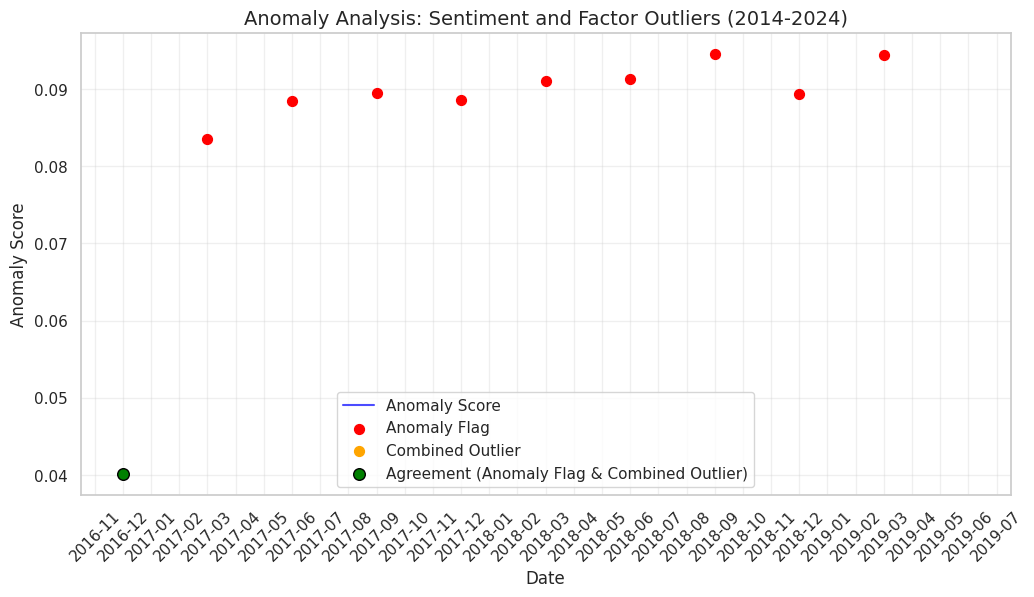

In [26]:
# Filter data for the agreed period: 2014-2024
filtered_data = merged_data[
    (merged_data['Date'] >= "2014-01") & (merged_data['Date'] <= "2024-12")
]

# Add a column indicating agreement between 'Anomaly Flag' and 'Combined Outlier'
filtered_data['Agreement'] = (
    (filtered_data['Anomaly Flag'] == 'Anomaly') & (filtered_data['Combined_Outlier'])
)

# Create a plot visualizing the 'Anomaly Flag', 'Combined Outlier', and agreement
plt.figure(figsize=(12, 6))

# Plot 'Anomaly Score'
plt.plot(
    filtered_data['Date'],
    filtered_data['Anomaly Score'],
    label='Anomaly Score',
    color='blue',
    alpha=0.7
)

# Highlight 'Anomaly Flag'
anomaly_flag_dates = filtered_data[filtered_data['Anomaly Flag'] == 'Anomaly']['Date']
plt.scatter(
    anomaly_flag_dates,
    filtered_data.loc[filtered_data['Anomaly Flag'] == 'Anomaly', 'Anomaly Score'],
    label='Anomaly Flag',
    color='red',
    s=50
)

# Highlight 'Combined Outliers'
combined_outlier_dates = filtered_data[filtered_data['Combined_Outlier']]['Date']
plt.scatter(
    combined_outlier_dates,
    filtered_data.loc[filtered_data['Combined_Outlier'], 'Anomaly Score'],
    label='Combined Outlier',
    color='orange',
    s=50
)

# Highlight Agreement
agreement_dates = filtered_data[filtered_data['Agreement']]['Date']
plt.scatter(
    agreement_dates,
    filtered_data.loc[filtered_data['Agreement'], 'Anomaly Score'],
    label='Agreement (Anomaly Flag & Combined Outlier)',
    color='green',
    s=70,
    edgecolor='black'
)

# Formatting
plt.title('Anomaly Analysis: Sentiment and Factor Outliers (2014-2024)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Anomaly Score', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()



**All anomalies**